# 카테고리 간 비교
```text
1. DoS/DDoS vs Brute Force  공통 feature 많음
2. DoS/DDoS vs Botnet       시간 feature 둘 다 낮음 
3. Brute Force vs Botnet    flow duration 둘 다 낮음
```

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv(r'C:\Users\3eunh\OneDrive\Desktop\NS\code\data\05_train_with_category.csv')

# 숫자형 컬럼 (Label, Category 제외)
exclude_cols = ['Label', 'Category']
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

In [2]:
# 카테고리 간 비교 함수

def compare_two_categories(df, cat1, cat2, numeric_cols, top_n=15):
    """
    두 카테고리 직접 비교
    """
    data1 = df[df['Category'] == cat1]
    data2 = df[df['Category'] == cat2]
    
    print(f"\n{'='*70}")
    print(f"[{cat1}] vs [{cat2}]")
    print(f"{'='*70}")
    print(f"{cat1}: {len(data1)}개 샘플")
    print(f"{cat2}: {len(data2)}개 샘플")
    
    results = []
    
    for feat in numeric_cols:
        vals1 = data1[feat].replace([np.inf, -np.inf], np.nan).dropna()
        vals2 = data2[feat].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(vals1) < 10 or len(vals2) < 10:
            continue
        
        mean1 = vals1.mean()
        mean2 = vals2.mean()
        std1 = vals1.std()
        std2 = vals2.std()
        
        # Ratio (cat1 / cat2)
        if mean2 != 0:
            ratio = mean1 / mean2
        else:
            ratio = np.inf if mean1 > 0 else 0
        
        # Welch's t-test
        t_stat, p_value = stats.ttest_ind(vals1, vals2, equal_var=False)
        
        # Cohen's d
        pooled_std = np.sqrt((std1**2 + std2**2) / 2)
        if pooled_std > 0:
            cohens_d = abs(mean1 - mean2) / pooled_std
        else:
            cohens_d = 0
        
        # 방향 (어느 쪽이 높은지)
        if mean1 > mean2:
            direction = f"{cat1} > {cat2}"
        else:
            direction = f"{cat2} > {cat1}"
        
        results.append({
            'Feature': feat,
            f'{cat1}_Mean': mean1,
            f'{cat2}_Mean': mean2,
            'Ratio': ratio,
            'Cohen_d': cohens_d,
            'p_value': p_value,
            'Direction': direction
        })
    
    # DataFrame으로 변환
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Cohen_d', ascending=False)
    
    return results_df


In [3]:
# 핵심 3쌍 비교

# 비교 1: DoS/DDoS vs Brute Force
print("\n" + "="*70)
print("비교 1: DoS/DDoS vs Brute Force")
print("="*70)
comp1 = compare_two_categories(df, 'DoS/DDoS', 'Brute Force', numeric_cols)

# 비교 2: DoS/DDoS vs Botnet
print("\n" + "="*70)
print("비교 2: DoS/DDoS vs Botnet")
print("="*70)
comp2 = compare_two_categories(df, 'DoS/DDoS', 'Botnet', numeric_cols)

# 비교 3: Brute Force vs Botnet
print("\n" + "="*70)
print("비교 3: Brute Force vs Botnet")
print("="*70)
comp3 = compare_two_categories(df, 'Brute Force', 'Botnet', numeric_cols)



비교 1: DoS/DDoS vs Brute Force

[DoS/DDoS] vs [Brute Force]
DoS/DDoS: 8145개 샘플
Brute Force: 2324개 샘플

비교 2: DoS/DDoS vs Botnet

[DoS/DDoS] vs [Botnet]
DoS/DDoS: 8145개 샘플
Botnet: 1327개 샘플


c:\Users\3eunh\OneDrive\Desktop\NS\code\pt_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



비교 3: Brute Force vs Botnet

[Brute Force] vs [Botnet]
Brute Force: 2324개 샘플
Botnet: 1327개 샘플


In [4]:
# 결과 출력: Top 10 구별 Feature

def print_top_features(comp_df, cat1, cat2, top_n=10):
    print(f"\n[{cat1} vs {cat2}] 구별력 높은 Top {top_n} Feature")
    print("-" * 80)
    
    top = comp_df.head(top_n)
    for i, row in top.iterrows():
        print(f"{row['Feature']:30s} | Cohen's d: {row['Cohen_d']:6.2f} | "
              f"Ratio: {row['Ratio']:10.4f} | {row['Direction']}")

print_top_features(comp1, 'DoS/DDoS', 'Brute Force')
print_top_features(comp2, 'DoS/DDoS', 'Botnet')
print_top_features(comp3, 'Brute Force', 'Botnet')



[DoS/DDoS vs Brute Force] 구별력 높은 Top 10 Feature
--------------------------------------------------------------------------------
Dst Port                       | Cohen's d:   2.24 | Ratio:     3.0089 | DoS/DDoS > Brute Force
Bwd Pkts/s                     | Cohen's d:   1.89 | Ratio:     0.1752 | Brute Force > DoS/DDoS
Flow Pkts/s                    | Cohen's d:   1.89 | Ratio:     0.1753 | Brute Force > DoS/DDoS
Fwd Pkts/s                     | Cohen's d:   1.89 | Ratio:     0.1754 | Brute Force > DoS/DDoS
Pkt Len Mean                   | Cohen's d:   1.81 | Ratio:        inf | DoS/DDoS > Brute Force
Pkt Size Avg                   | Cohen's d:   1.79 | Ratio:        inf | DoS/DDoS > Brute Force
Pkt Len Max                    | Cohen's d:   1.66 | Ratio:        inf | DoS/DDoS > Brute Force
Init Bwd Win Byts              | Cohen's d:   1.65 | Ratio:        inf | DoS/DDoS > Brute Force
Pkt Len Std                    | Cohen's d:   1.64 | Ratio:        inf | DoS/DDoS > Brute Force
TotLen

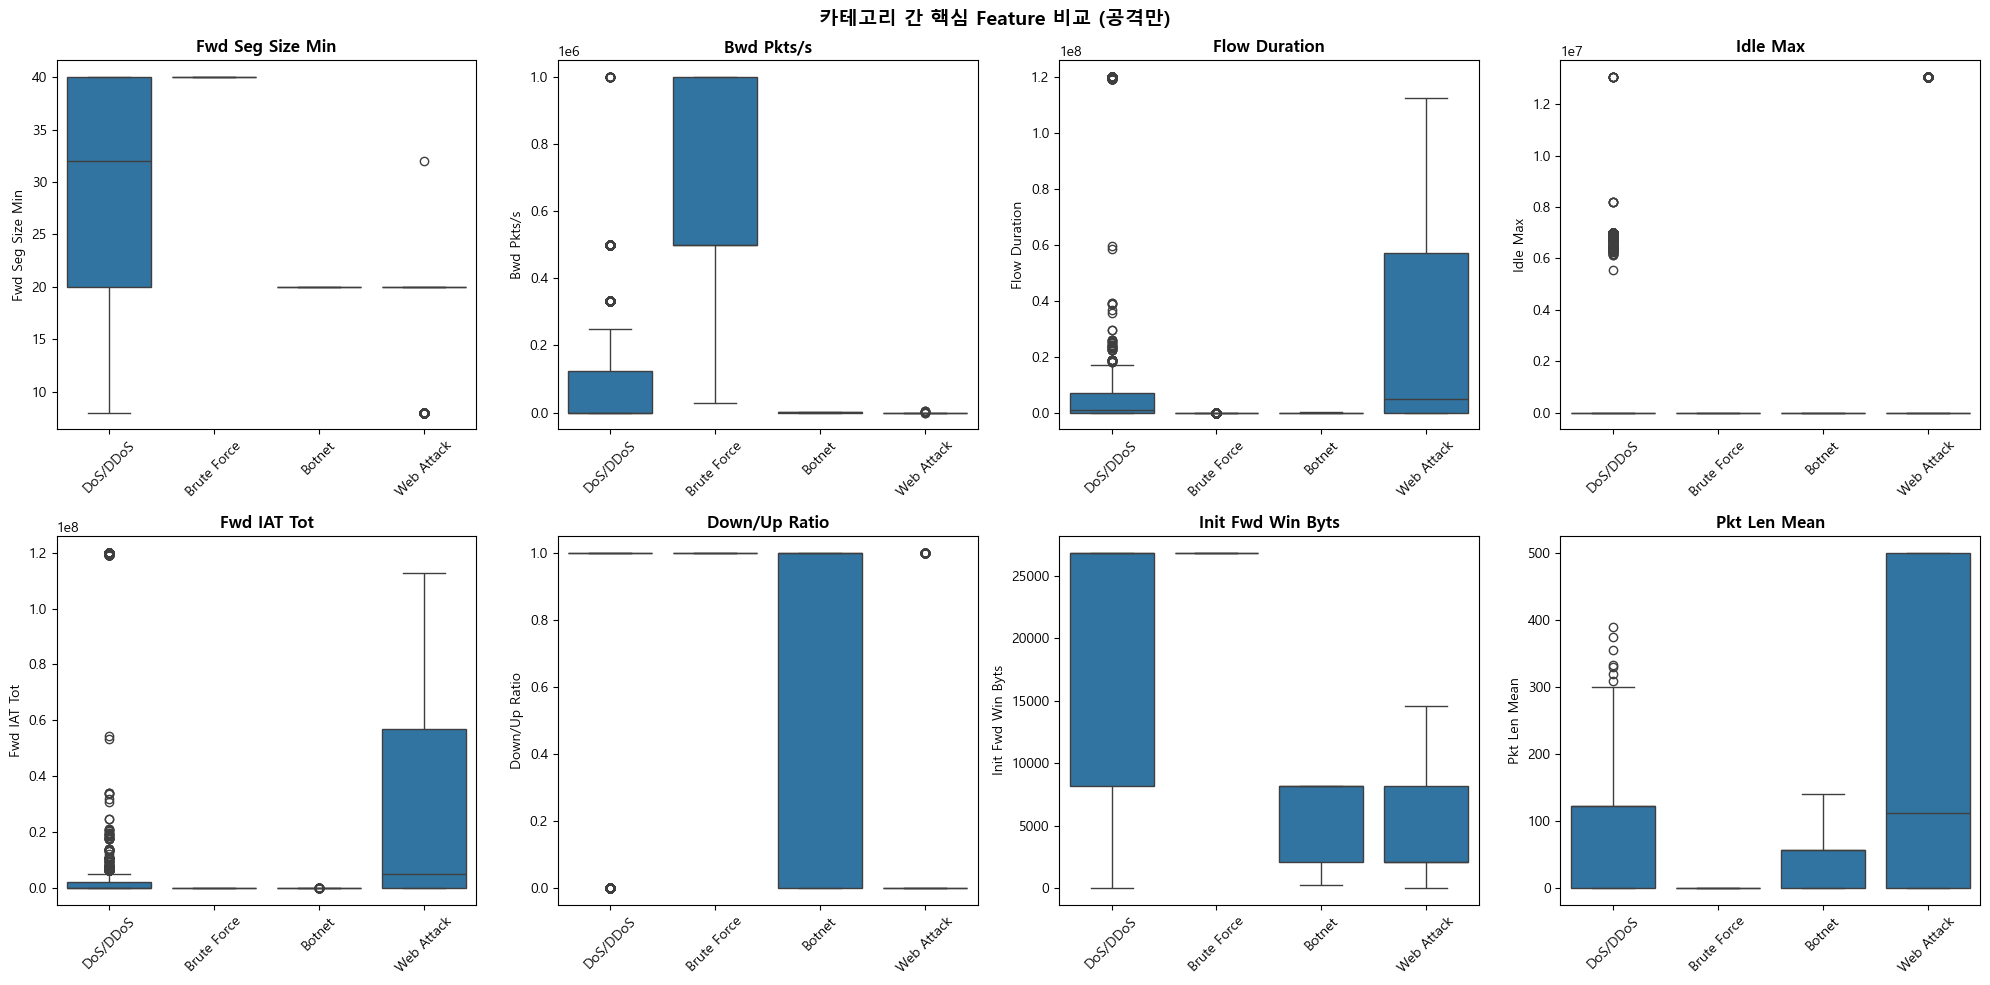

In [5]:
# 시각화: 핵심 Feature 비교 Box Plot


# 관심 Feature 목록 (각 카테고리 Rule에서 사용하는 것들)
key_features = [
    'Fwd Seg Size Min',      # Brute Force 고유
    'Bwd Pkts/s',            # Brute Force 높음
    'Flow Duration',         # Brute Force, Botnet 낮음
    'Idle Max',              # DoS/DDoS 낮음
    'Fwd IAT Tot',           # Botnet 극도로 낮음
    'Down/Up Ratio',         # DoS, Brute 높음
    'Init Fwd Win Byts',     # DoS, Brute 높음
    'Pkt Len Mean'           # Botnet 낮음
]

# 공격 카테고리만 추출 (Benign 제외)
attacks_only = df[df['Category'] != 'Benign'].copy()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in attacks_only.columns:
        ax = axes[i]
        
        # 이상치 제거를 위해 log scale 또는 percentile clip
        plot_data = attacks_only[[feat, 'Category']].copy()
        
        # 극단값 클리핑 (1%, 99%)
        lower = plot_data[feat].quantile(0.01)
        upper = plot_data[feat].quantile(0.99)
        plot_data[feat] = plot_data[feat].clip(lower, upper)
        
        sns.boxplot(data=plot_data, x='Category', y=feat, ax=ax,
                   order=['DoS/DDoS', 'Brute Force', 'Botnet', 'Web Attack'])
        ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

plt.suptitle('카테고리 간 핵심 Feature 비교 (공격만)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()